In [1]:
# Data cleaning 
import pandas as pd 
import numpy as np
df = pd.read_csv("D:\\Student_Performance_Project\\dataset\\student_data.csv")
df

,Student ID,Student Name,Age,Gender,Course,Year,Attendance,Internal Marks,External Marks,Assignment Score,Study Hours,Internet Usage,Result,City
0,S1,Isha,17.0,Female,BA,Second,NaN,20.0,NaN,NaN,33,15,pass,Punea
1,S2,Karan,19.0,m,BCA,Second,NaN,NaN,37.0,19.0,0,6,Pass,Punea
2,S3,Isha,NaN,FEMALE,BSc,TY,61.0,NaN,59.0,20.0,24,2,FAIL,Nashik
3,S4,Karan,NaN,FEMALE,BA,1st,120.0,22.0,41.0,11.0,0,5,FAIL,Pune
4,S5,Anaya,20.0,Male,BCA,TY,95.0,NaN,NaN,NaN,80,15,Fail,Nashik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,S1096,Aarav,5.0,FEMALE,BCom,FY,NaN,NaN,NaN,11.0,0,15,pass,Nashikk
1096,S1097,Pooja,24.0,FEMALE,BCom,SY,NaN,NaN,NaN,13.0,80,15,Pass,Pune
1097,S1098,Aditya,5.0,Male,BSc,FY,120.0,NaN,NaN,12.0,1,8,pass,Mumbai
1098,S1099,Vihaan,120.0,Female,BCA,SY,50.0,27.0,NaN,11.0,14,7,Fail,Pune


In [2]:
df.head(10)

,Student ID,Student Name,Age,Gender,Course,Year,Attendance,Internal Marks,External Marks,Assignment Score,Study Hours,Internet Usage,Result,City
0,S1,Isha,17.0,Female,BA,Second,NaN,20.0,NaN,NaN,33,15,pass,Punea
1,S2,Karan,19.0,m,BCA,Second,NaN,NaN,37.0,19.0,0,6,Pass,Punea
2,S3,Isha,NaN,FEMALE,BSc,TY,61.0,NaN,59.0,20.0,24,2,FAIL,Nashik
3,S4,Karan,NaN,FEMALE,BA,1st,120.0,22.0,41.0,11.0,0,5,FAIL,Pune
4,S5,Anaya,20.0,Male,BCA,TY,95.0,NaN,NaN,NaN,80,15,Fail,Nashik
5,S6,Vihaan,120.0,Female,BCom,FY,120.0,NaN,NaN,NaN,8,15,pass,Nashikk
6,S7,Vihaan,NaN,Male,BA,TY,NaN,40.0,NaN,NaN,5,15,FAIL,Nashik
7,S8,Anaya,NaN,Male,BCom,TY,NaN,21.0,43.0,NaN,15,15,FAIL,Mumbai
8,S9,Rohan,NaN,Female,BSc,1st,NaN,37.0,NaN,11.0,32,15,FAIL,Nashikk
9,S10,Aditya,120.0,Female,BBA,SY,65.0,NaN,NaN,NaN,80,15,Pass,Nashik


In [3]:
print("\n Shape")
print(df.shape)


 Shape
(1100, 14)


In [4]:
print("\n Columns")
print(df.columns)


 Columns
Index(['Student ID', 'Student Name', 'Age', 'Gender', 'Course', 'Year',
       'Attendance', 'Internal Marks', 'External Marks', 'Assignment Score',
       'Study Hours', 'Internet Usage', 'Result', 'City'],
      dtype='object')


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student ID        1100 non-null   object 
 1   Student Name      1100 non-null   object 
 2   Age               830 non-null    float64
 3   Gender            1100 non-null   object 
 4   Course            1100 non-null   object 
 5   Year              1100 non-null   object 
 6   Attendance        739 non-null    float64
 7   Internal Marks    536 non-null    float64
 8   External Marks    558 non-null    float64
 9   Assignment Score  531 non-null    float64
 10  Study Hours       1100 non-null   int64  
 11  Internet Usage    1100 non-null   int64  
 12  Result            1100 non-null   object 
 13  City              1100 non-null   object 
dtypes: float64(5), int64(2), object(7)
memory usage: 120.4+ KB
None


In [6]:
print(df.isnull().sum())

Student ID            0
Student Name          0
Age                 270
Gender                0
Course                0
Year                  0
Attendance          361
Internal Marks      564
External Marks      542
Assignment Score    569
Study Hours           0
Internet Usage        0
Result                0
City                  0
dtype: int64


In [7]:
print("Duplicate Rows",df.duplicated().sum())

Duplicate Rows 0


In [8]:
#handling numeric missing values
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

In [9]:
print(df.isnull().sum())

Student ID          0
Student Name        0
Age                 0
Gender              0
Course              0
Year                0
Attendance          0
Internal Marks      0
External Marks      0
Assignment Score    0
Study Hours         0
Internet Usage      0
Result              0
City                0
dtype: int64


In [10]:
#Standardize gender column
print(df['Gender'].unique())

['Female' 'm' 'FEMALE' 'Male']


In [11]:
df['Gender'] = df['Gender'].str.upper()
df['Gender'] = df['Gender'].replace({
    'M': 'MALE',
    'FEMALE' : 'FEMALE',
    'FEMALE' : 'FEMALE',
    'MALE':'MALE'})

In [12]:
print(df['Gender'].unique())

['FEMALE' 'MALE']


In [13]:
#Standardize result column
print(df['Result'].unique())

['pass' 'Pass' 'FAIL' 'Fail']


In [14]:
df['Result'] = df['Result'].str.upper()
df['Result'] = df['Result'].replace({
    'PASS' : 'PASS',
    'FAIL' : 'FAIL'})

In [15]:
print(df['Result'].unique())

['PASS' 'FAIL']


In [16]:
#remove exta spaces 
categorical_columns = df.select_dtypes(include='object').columns
for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip()

In [17]:
print(df['Year'].unique())

['Second' 'TY' '1st' 'FY' 'SY']


In [18]:
# standardizing year column
df['Year'] = df['Year'].str.upper()
df['Year'] = df['Year'].replace({
    'SECOND':'SY',
    'TY' : 'TY',
    '1ST' : 'FY',
    'FY' : 'FY',
    'SY' : 'SY'})



In [19]:
#standardizing City column
print(df['Year'].unique())

['SY' 'TY' 'FY']


In [20]:
print(df['City'].unique())

['Punea' 'Nashik' 'Pune' 'Nashikk' 'Mumbai']


In [21]:
df['City'] = df['City'].replace({
    'Punea':'Pune',
    'Nashikk' : 'Nashik'})

In [22]:
print(df['City'].unique())

['Pune' 'Nashik' 'Mumbai']


In [23]:
#outlier Detection
df[df['Attendance']>100]

,Student ID,Student Name,Age,Gender,Course,Year,Attendance,Internal Marks,External Marks,Assignment Score,Study Hours,Internet Usage,Result,City
3,S4,Karan,49.215663,FEMALE,BA,FY,120.0,22.000000,41.000000,11.000000,0,5,FAIL,Pune
5,S6,Vihaan,120.000000,FEMALE,BCom,FY,120.0,29.735075,44.820789,15.308851,8,15,PASS,Nashik
12,S13,Aarav,5.000000,FEMALE,BBA,SY,120.0,31.000000,44.820789,15.308851,2,1,PASS,Nashik
13,S14,Anaya,49.215663,MALE,BSc,FY,120.0,25.000000,36.000000,12.000000,0,15,FAIL,Pune
16,S17,Vihaan,120.000000,MALE,BBA,FY,120.0,29.735075,45.000000,15.308851,80,15,FAIL,Mumbai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1084,S1085,Anaya,49.215663,MALE,BCA,TY,120.0,29.735075,44.820789,18.000000,80,3,FAIL,Mumbai
1089,S1090,Saanvi,49.215663,FEMALE,BCom,SY,120.0,24.000000,32.000000,11.000000,17,15,FAIL,Pune
1090,S1091,Pooja,49.215663,FEMALE,BSc,SY,120.0,21.000000,42.000000,15.308851,7,15,PASS,Mumbai
1094,S1095,Rohan,120.000000,FEMALE,BCA,FY,120.0,23.000000,38.000000,16.000000,8,15,FAIL,Pune


In [24]:
df.loc[df['Attendance']>100,'Attendance'] = 100

In [25]:
print(df['Attendance'].max())

100.0


In [26]:
df['Age'] = df['Age'].clip(lower=15, upper=25)

In [27]:
df['Study Hours'] = df['Study Hours'].clip(lower=0, upper=12)

In [28]:
print(df.head())

  Student ID Student Name   Age  Gender Course Year  Attendance  \
0         S1         Isha  17.0  FEMALE     BA   SY   98.010825   
1         S2        Karan  19.0    MALE    BCA   SY   98.010825   
2         S3         Isha  25.0  FEMALE    BSc   TY   61.000000   
3         S4        Karan  25.0  FEMALE     BA   FY  100.000000   
4         S5        Anaya  20.0    MALE    BCA   TY   95.000000   

   Internal Marks  External Marks  Assignment Score  Study Hours  \
0       20.000000       44.820789         15.308851           12   
1       29.735075       37.000000         19.000000            0   
2       29.735075       59.000000         20.000000           12   
3       22.000000       41.000000         11.000000            0   
4       29.735075       44.820789         15.308851           12   

   Internet Usage Result    City  
0              15   PASS    Pune  
1               6   PASS    Pune  
2               2   FAIL  Nashik  
3               5   FAIL    Pune  
4            

In [29]:
df['Age'] = df['Age'].round(0)

df['Attendance'] = df['Attendance'].round(0)

df['Internal Marks'] =df['Internal Marks'].round(0)

df['External Marks'] = df['External Marks'].round(0)

df['Assignment Score'] = df['Assignment Score'].round(0)

In [30]:
print(df.isnull().sum())

Student ID          0
Student Name        0
Age                 0
Gender              0
Course              0
Year                0
Attendance          0
Internal Marks      0
External Marks      0
Assignment Score    0
Study Hours         0
Internet Usage      0
Result              0
City                0
dtype: int64


In [31]:
df.to_csv("D:\\Student_Performance_Project\\dataset\\cleaned_student_data.csv",index=False)

In [32]:
# Exploratory Data Analysis(EDA)

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("D:\\Student_Performance_Project\\dataset\\cleaned_student_data.csv")
df

,Student ID,Student Name,Age,Gender,Course,Year,Attendance,Internal Marks,External Marks,Assignment Score,Study Hours,Internet Usage,Result,City
0,S1,Isha,17.0,FEMALE,BA,SY,98.0,20.0,45.0,15.0,12,15,PASS,Pune
1,S2,Karan,19.0,MALE,BCA,SY,98.0,30.0,37.0,19.0,0,6,PASS,Pune
2,S3,Isha,25.0,FEMALE,BSc,TY,61.0,30.0,59.0,20.0,12,2,FAIL,Nashik
3,S4,Karan,25.0,FEMALE,BA,FY,100.0,22.0,41.0,11.0,0,5,FAIL,Pune
4,S5,Anaya,20.0,MALE,BCA,TY,95.0,30.0,45.0,15.0,12,15,FAIL,Nashik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,S1096,Aarav,15.0,FEMALE,BCom,FY,98.0,30.0,45.0,11.0,0,15,PASS,Nashik
1096,S1097,Pooja,24.0,FEMALE,BCom,SY,98.0,30.0,45.0,13.0,12,15,PASS,Pune
1097,S1098,Aditya,15.0,MALE,BSc,FY,100.0,30.0,45.0,12.0,1,8,PASS,Mumbai
1098,S1099,Vihaan,25.0,FEMALE,BCA,SY,50.0,27.0,45.0,11.0,12,7,FAIL,Pune


In [35]:
#basic Statistics 
print(df.describe())

               Age   Attendance  Internal Marks  External Marks  \
count  1100.000000  1100.000000     1100.000000     1100.000000   
mean     21.412727    91.007273       29.870909       44.909091   
std       4.331217    14.281963        4.229932        6.522231   
min      15.000000    50.000000       20.000000       30.000000   
25%      15.000000    88.000000       30.000000       45.000000   
50%      25.000000    98.000000       30.000000       45.000000   
75%      25.000000   100.000000       30.000000       45.000000   
max      25.000000   100.000000       40.000000       60.000000   

       Assignment Score  Study Hours  Internet Usage  
count       1100.000000  1100.000000     1100.000000  
mean          15.149091     7.416364       10.047273  
std            2.223530     5.596641        5.456715  
min           10.000000     0.000000        1.000000  
25%           15.000000     0.000000        5.000000  
50%           15.000000    12.000000       15.000000  
75%        

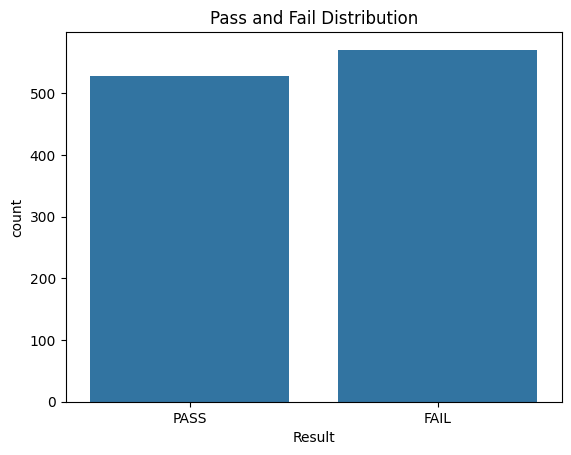

In [36]:
#Result Distribution Graph 
sns.countplot(x='Result',data = df)
plt.title ("Pass and Fail Distribution")
plt.show()

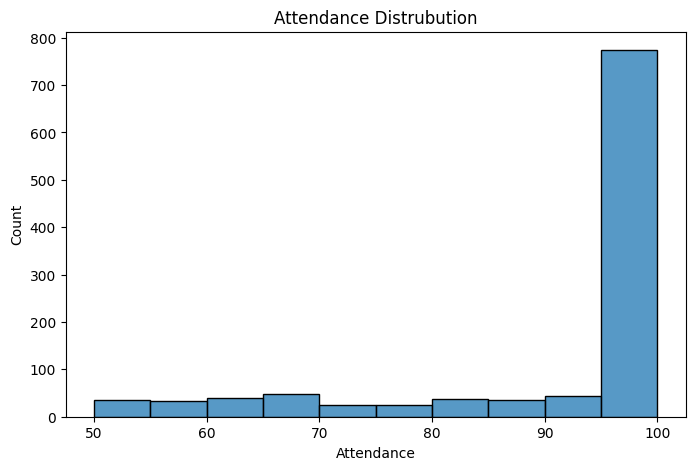

In [37]:
#Attendence distribution graph
plt.figure(figsize=(8,5))
sns.histplot(df['Attendance'],bins = 10)
plt.title("Attendance Distrubution")
plt.show()

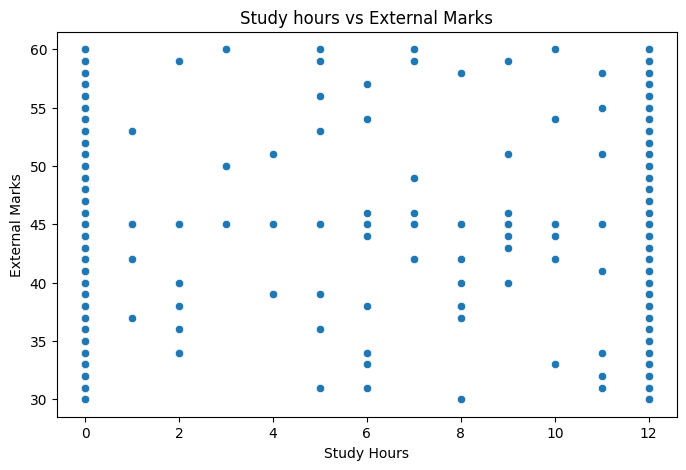

In [38]:
#Study hours vs External Marks
plt.figure(figsize=(8,5))
sns.scatterplot(x = 'Study Hours',y = 'External Marks',data = df)
plt.title("Study hours vs External Marks")
plt.show()


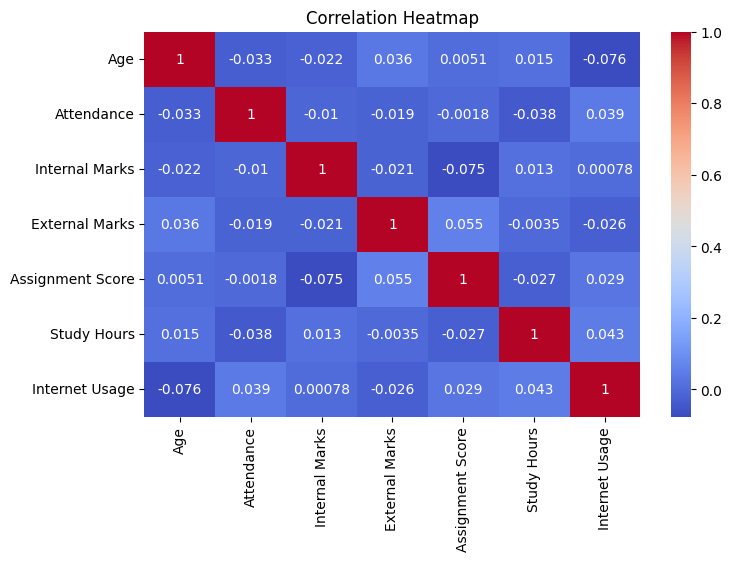

In [39]:
#COREELATION HEATMAP
plt.figure(figsize = (8,5))
numeric_df = df.select_dtypes(include = 'number')
sns.heatmap(numeric_df.corr(), annot=True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [40]:
#Top performing student 
top_student = df.sort_values(by='External Marks',ascending=False)
print(top_student[['Student Name','External Marks']].head(10))

     Student Name  External Marks
792          Isha            60.0
707         Rohan            60.0
883         Rohan            60.0
593        Aditya            60.0
56          Karan            60.0
394         Pooja            60.0
140          Isha            60.0
1043        Pooja            60.0
522         Pooja            60.0
827         Aarav            60.0


In [41]:
#Weak Student Detection 
weak_students = df[df['External Marks']<40]
print(weak_students[['Student Name','External Marks','Attendance']])

     Student Name  External Marks  Attendance
1           Karan            37.0        98.0
13          Anaya            36.0       100.0
18          Anaya            38.0        98.0
20          Karan            34.0        98.0
22          Aarav            35.0        95.0
...           ...             ...         ...
1074        Aarav            33.0       100.0
1077        Anaya            38.0        98.0
1085        Karan            33.0        54.0
1089       Saanvi            32.0       100.0
1094        Rohan            38.0       100.0

[193 rows x 3 columns]


In [42]:
# Risk level creation

In [43]:
df = pd.read_csv("D:\\Student_Performance_Project\\dataset\\cleaned_student_data.csv")
df

,Student ID,Student Name,Age,Gender,Course,Year,Attendance,Internal Marks,External Marks,Assignment Score,Study Hours,Internet Usage,Result,City
0,S1,Isha,17.0,FEMALE,BA,SY,98.0,20.0,45.0,15.0,12,15,PASS,Pune
1,S2,Karan,19.0,MALE,BCA,SY,98.0,30.0,37.0,19.0,0,6,PASS,Pune
2,S3,Isha,25.0,FEMALE,BSc,TY,61.0,30.0,59.0,20.0,12,2,FAIL,Nashik
3,S4,Karan,25.0,FEMALE,BA,FY,100.0,22.0,41.0,11.0,0,5,FAIL,Pune
4,S5,Anaya,20.0,MALE,BCA,TY,95.0,30.0,45.0,15.0,12,15,FAIL,Nashik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,S1096,Aarav,15.0,FEMALE,BCom,FY,98.0,30.0,45.0,11.0,0,15,PASS,Nashik
1096,S1097,Pooja,24.0,FEMALE,BCom,SY,98.0,30.0,45.0,13.0,12,15,PASS,Pune
1097,S1098,Aditya,15.0,MALE,BSc,FY,100.0,30.0,45.0,12.0,1,8,PASS,Mumbai
1098,S1099,Vihaan,25.0,FEMALE,BCA,SY,50.0,27.0,45.0,11.0,12,7,FAIL,Pune


In [44]:
# Creating risk function
def calculate_risk(row):

    score = 0

    # Attendance condition
    if row['Attendance'] < 60:
        score += 2

    elif row['Attendance'] < 75:
        score += 1

    # Internal marks condition
    if row['Internal Marks'] < 20:
        score += 2

    elif row['Internal Marks'] < 30:
        score += 1

    # Assignment condition
    if row['Assignment Score'] < 10:
        score += 2

    elif row['Assignment Score'] < 15:
        score += 1

    # Study hours condition
    if row['Study Hours'] < 2:
        score += 2

    elif row['Study Hours'] < 5:
        score += 1

    # Internet usage condition
    if row['Internet Usage'] > 12:
        score += 1

    # Final risk classification
    if score >= 5:
        return 'HIGH'
    elif score >= 2:
        return 'MEDIUM'
    else:
        return 'LOW'

In [45]:
df['Risk Level'] = df.apply(calculate_risk,axis=1)

In [46]:
print(df['Risk Level'].value_counts())

Risk Level
MEDIUM    595
LOW       478
HIGH       27
Name: count, dtype: int64


In [47]:
print(df[['Attendance', 'Internal Marks',
          'Assignment Score', 'Risk Level']].head())

   Attendance  Internal Marks  Assignment Score Risk Level
0        98.0            20.0              15.0     MEDIUM
1        98.0            30.0              19.0     MEDIUM
2        61.0            30.0              20.0        LOW
3       100.0            22.0              11.0     MEDIUM
4        95.0            30.0              15.0        LOW


In [48]:
#BULDING ML MODEL

In [49]:
from sklearn.preprocessing import LabelEncoder
risk_encoder = LabelEncoder()
df['Risk Level'] = risk_encoder.fit_transform(df['Risk Level'])

In [50]:
course_encoder = LabelEncoder()
df['Course'] = course_encoder.fit_transform(df['Course'])

In [51]:
year_encoder = LabelEncoder()
df['Year'] = year_encoder.fit_transform(df['Year'])

In [52]:
df['Gender'] = df['Gender'].map({
    'MALE': 1,
    'FEMALE': 0
})

In [53]:
result_encoder = LabelEncoder()
df['Result'] = result_encoder.fit_transform(df['Result'])

In [54]:
# Remove unnecessary column
df = df.drop(['Student ID','Student Name','City'],axis = 1)

In [55]:
print(df.isnull().sum())

Age                 0
Gender              0
Course              0
Year                0
Attendance          0
Internal Marks      0
External Marks      0
Assignment Score    0
Study Hours         0
Internet Usage      0
Result              0
Risk Level          0
dtype: int64


In [56]:
df.head()

,Age,Gender,Course,Year,Attendance,Internal Marks,External Marks,Assignment Score,Study Hours,Internet Usage,Result,Risk Level
0,17.0,0,0,1,98.0,20.0,45.0,15.0,12,15,1,2
1,19.0,1,2,1,98.0,30.0,37.0,19.0,0,6,1,2
2,25.0,0,4,2,61.0,30.0,59.0,20.0,12,2,0,1
3,25.0,0,0,0,100.0,22.0,41.0,11.0,0,5,0,2
4,20.0,1,2,2,95.0,30.0,45.0,15.0,12,15,0,1


In [57]:
# Seperate feture and target 
# Feture = input columns 
# Target = what we predict 
X = df.drop(['Risk Level','Result','External Marks'],axis = 1)
y= df['Risk Level']

In [58]:
# Train Test Split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42)


In [59]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=20, random_state=42)

In [60]:
y_pred_rf =rf_model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test,y_pred_rf)
print("Model Accuracy:",rf_accuracy)

Model Accuracy: 0.8954545454545455


In [62]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred_rf)
print(cm)

[[  0   0   6]
 [  0  87   8]
 [  0   9 110]]


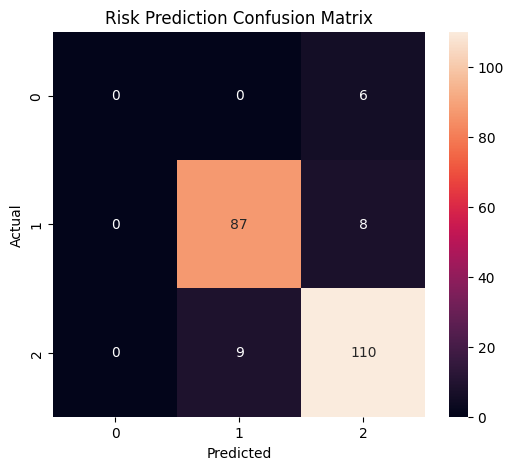

In [63]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot= True,fmt='d')
plt.title("Risk Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [64]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.91      0.92      0.91        95
           2       0.89      0.92      0.91       119

    accuracy                           0.90       220
   macro avg       0.60      0.61      0.61       220
weighted avg       0.87      0.90      0.88       220



C:\Users\patil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\patil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\patil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [65]:
importance = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

            Feature  Importance
7       Study Hours    0.540704
5    Internal Marks    0.193831
6  Assignment Score    0.104012
4        Attendance    0.102178
8    Internet Usage    0.045249
0               Age    0.007347
2            Course    0.003771
3              Year    0.001602
1            Gender    0.001307


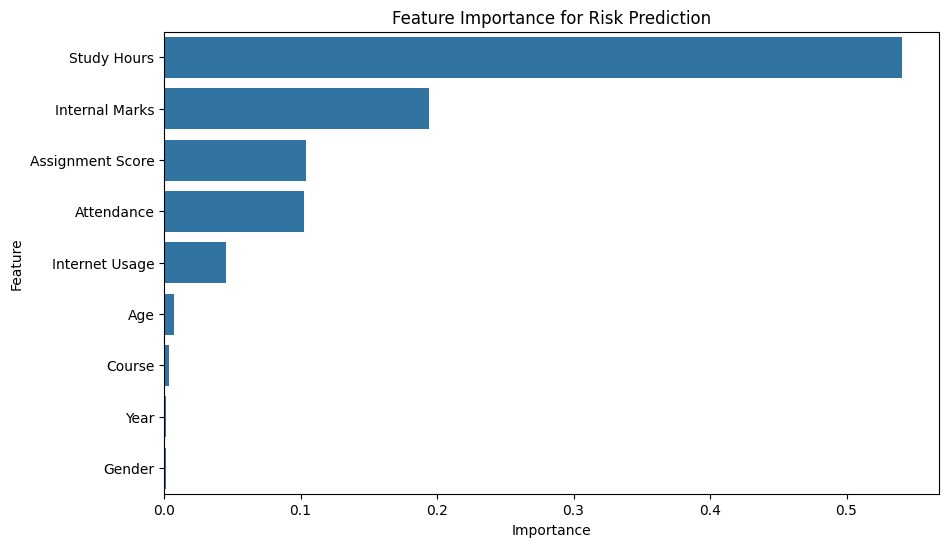

In [66]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance for Risk Prediction")

plt.show()

In [67]:
df.to_csv("D:\\Student_Performance_Project\\dataset\\Final_student_data.csv")

In [68]:
print(X.columns)

Index(['Age', 'Gender', 'Course', 'Year', 'Attendance', 'Internal Marks',
       'Assignment Score', 'Study Hours', 'Internet Usage'],
      dtype='object')


In [69]:
sample_student = [[
    20,
    1,    # Gender (MALE)
    1,    # Course
    2,    # Year
    55,   # Attendance
    18,
    10,
    2,
    14    # Internet Usage
]]
prediction = rf_model.predict(sample_student)

predicted_label = risk_encoder.inverse_transform(prediction)

print("Predicted Risk Level:", predicted_label[0])

Predicted Risk Level: MEDIUM


C:\Users\patil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [70]:
import joblib

joblib.dump(rf_model, "D:\\Student_Performance_Project\\model\\student_risk_model.pkl")

['D:\\Student_Performance_Project\\model\\student_risk_model.pkl']

In [71]:
import pandas as pd 
dashboard_df = pd.read_csv("../dataset/cleaned_student_data.csv")
dashboard_df

,Student ID,Student Name,Age,Gender,Course,Year,Attendance,Internal Marks,External Marks,Assignment Score,Study Hours,Internet Usage,Result,City
0,S1,Isha,17.0,FEMALE,BA,SY,98.0,20.0,45.0,15.0,12,15,PASS,Pune
1,S2,Karan,19.0,MALE,BCA,SY,98.0,30.0,37.0,19.0,0,6,PASS,Pune
2,S3,Isha,25.0,FEMALE,BSc,TY,61.0,30.0,59.0,20.0,12,2,FAIL,Nashik
3,S4,Karan,25.0,FEMALE,BA,FY,100.0,22.0,41.0,11.0,0,5,FAIL,Pune
4,S5,Anaya,20.0,MALE,BCA,TY,95.0,30.0,45.0,15.0,12,15,FAIL,Nashik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,S1096,Aarav,15.0,FEMALE,BCom,FY,98.0,30.0,45.0,11.0,0,15,PASS,Nashik
1096,S1097,Pooja,24.0,FEMALE,BCom,SY,98.0,30.0,45.0,13.0,12,15,PASS,Pune
1097,S1098,Aditya,15.0,MALE,BSc,FY,100.0,30.0,45.0,12.0,1,8,PASS,Mumbai
1098,S1099,Vihaan,25.0,FEMALE,BCA,SY,50.0,27.0,45.0,11.0,12,7,FAIL,Pune


In [72]:
dashboard_df['Risk Level'] = dashboard_df['Risk Level'].replace({
    0: 'HIGH',
    1: 'LOW',
    2: 'MEDIUM'
})

KeyError: 'Risk Level'

In [ ]:
dashboard_df['Risk Level'] = df['Risk Level']

In [ ]:
dashboard_df.to_csv(
    "../dataset/final_student_risk_data_final.csv",
    index=False
)


In [ ]:
dashboard_df = pd.read_csv("../dataset/final_student_risk_data_final.csv")
dashboard_df